# Interpreting Black-Box Models using SHAP and XGBoost

**Student Name:** Mahesh Vemuri


This tutorial demonstrates how SHAP (SHapley Additive Explanations) can be used to interpret machine learning models, specifically XGBoost, on a classification task.

In [ ]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from xgboost import XGBClassifier
import shap

# Style (colorblind-friendly)
plt.style.use("seaborn-v0_8-colorblind")

### Load Dataset

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.head())
print("\nDataset shape:", X.shape)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

### Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Train XGBoost Model

In [ ]:
model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

### Model Evaluation

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315
ROC-AUC: 0.9947089947089947

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### Feature Importance Plot

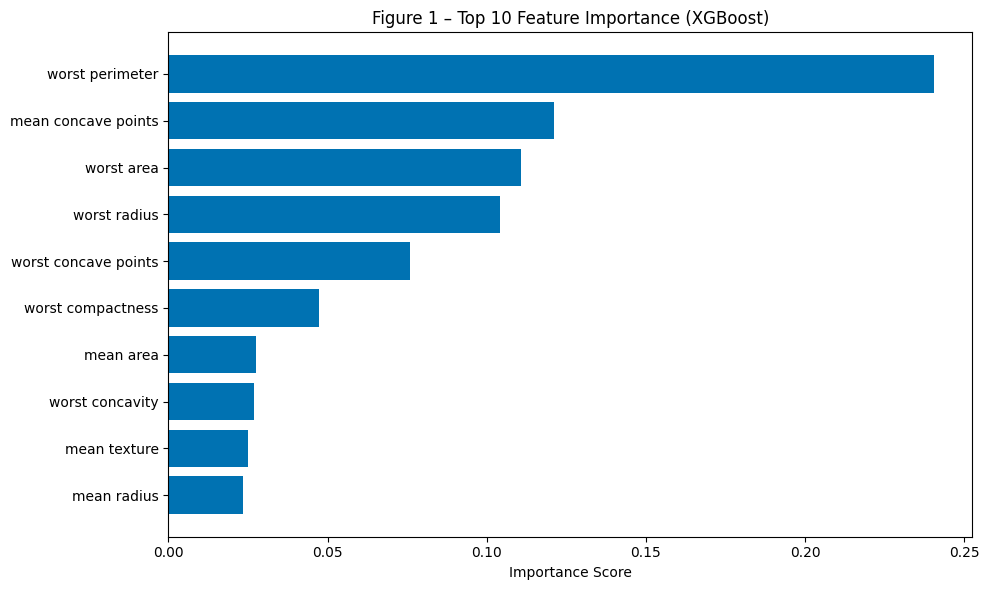

In [ ]:
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Importance Score")
plt.title("Figure 1 – Top 10 Feature Importance (XGBoost)")

plt.tight_layout()
plt.savefig("figure1_feature_importance.png", dpi=300)
plt.show()

### SHAP Explainer

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

### SHAP Summary Plot

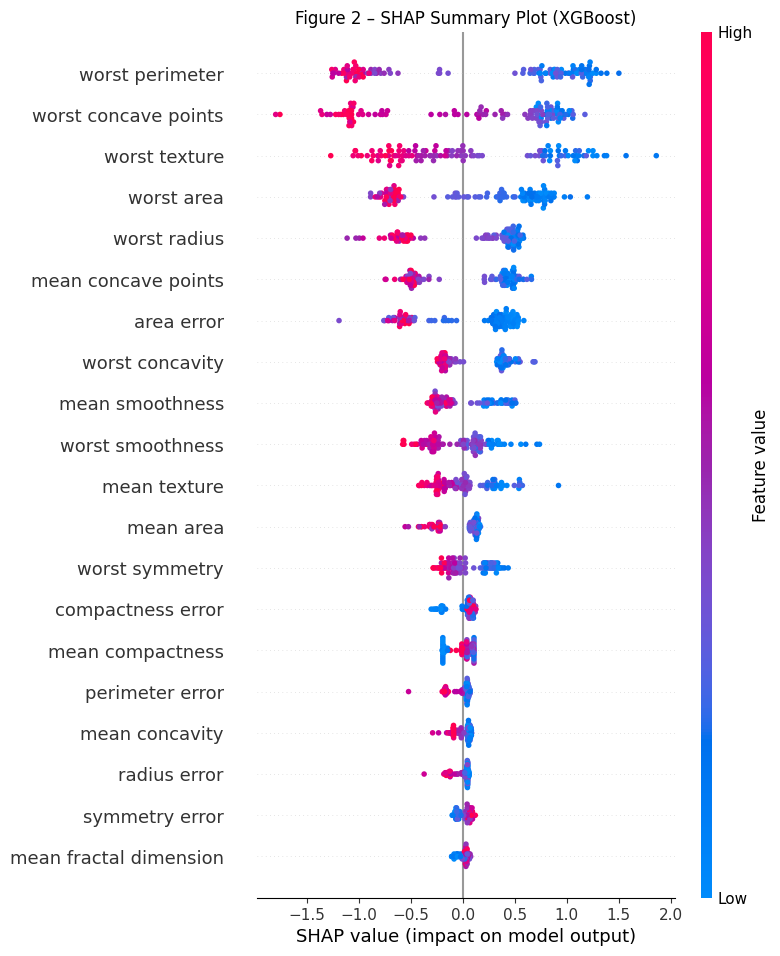

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)

plt.title("Figure 2 – SHAP Summary Plot (XGBoost)")
plt.savefig("figure2_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

### SHAP Beeswarm Plot

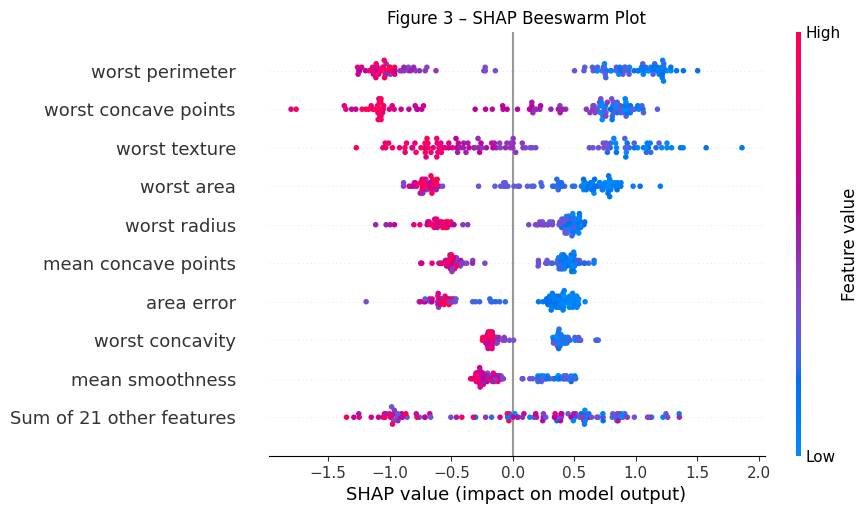

In [ ]:
plt.figure()
shap.plots.beeswarm(shap.Explanation(values=shap_values, data=X_test), show=False)

plt.title("Figure 3 – SHAP Beeswarm Plot")
plt.savefig("figure3_shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

### SHAP Dependence Plot

<Figure size 640x480 with 0 Axes>

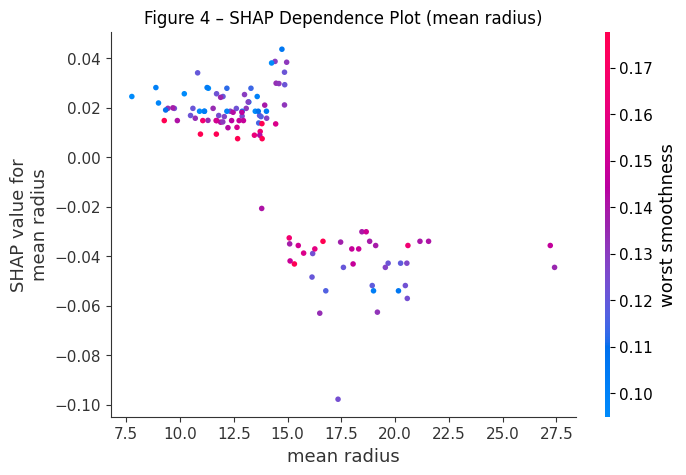

In [ ]:
feature_name = X.columns[0]  # we can change

plt.figure()
shap.dependence_plot(feature_name, shap_values, X_test, show=False)

plt.title(f"Figure 4 – SHAP Dependence Plot ({feature_name})")
plt.savefig("figure4_dependence.png", dpi=300, bbox_inches="tight")
plt.show()

### SHAP Force Plot (Single Prediction)

In [ ]:
sample_index = 0

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index]
)

force_plot

### SHAP Interaction Values

<Figure size 640x480 with 0 Axes>

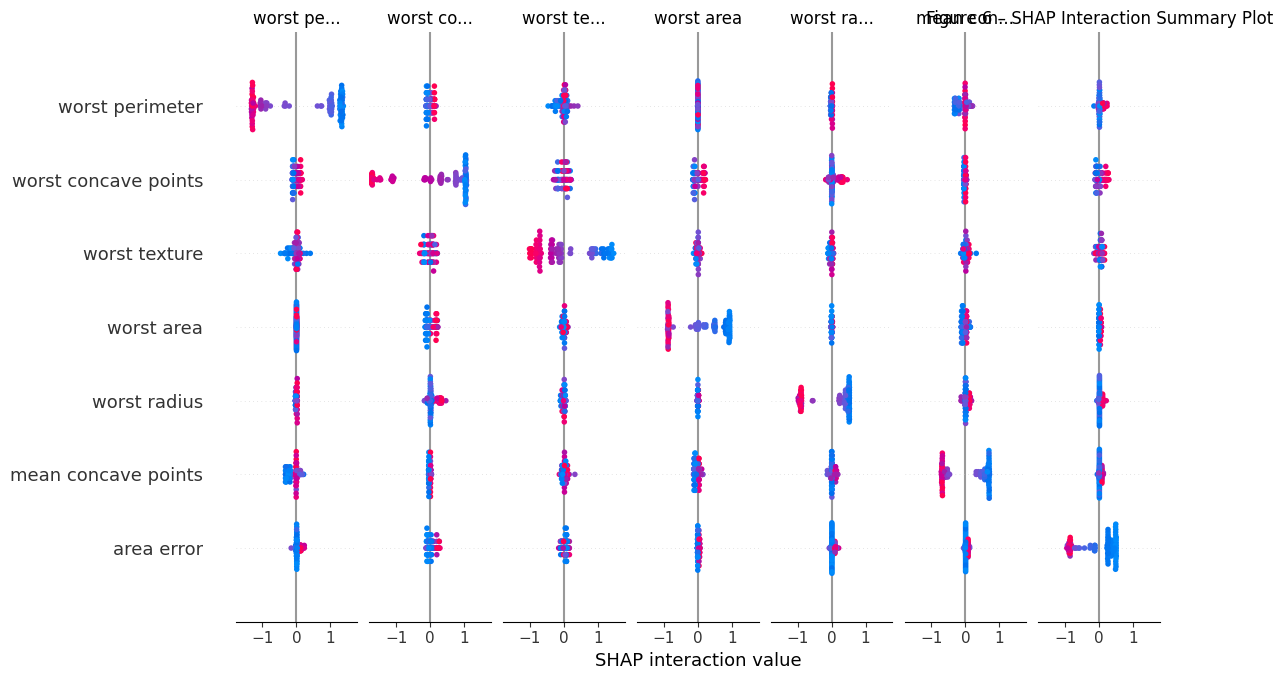

In [ ]:

interaction_values = explainer.shap_interaction_values(X_test)
plt.figure()
shap.summary_plot(interaction_values, X_test, show=False)

plt.title("Figure 6 – SHAP Interaction Summary Plot")
plt.savefig("figure6_shap_interaction_summary.png", dpi=300, bbox_inches="tight")
plt.show()

### Strongest Interaction Pair

In [ ]:
interaction_strength = np.abs(interaction_values).mean(axis=0)

# Ignore diagonal (self-interactions)
np.fill_diagonal(interaction_strength, 0)

# Get top interacting feature pair
i, j = np.unravel_index(np.argmax(interaction_strength), interaction_strength.shape)

feature_1 = X.columns[i]
feature_2 = X.columns[j]

print(f"Strongest interaction between: {feature_1} and {feature_2}")

Strongest interaction between: mean concave points and worst perimeter


### SHAP Dependence Plot with Interaction

<Figure size 640x480 with 0 Axes>

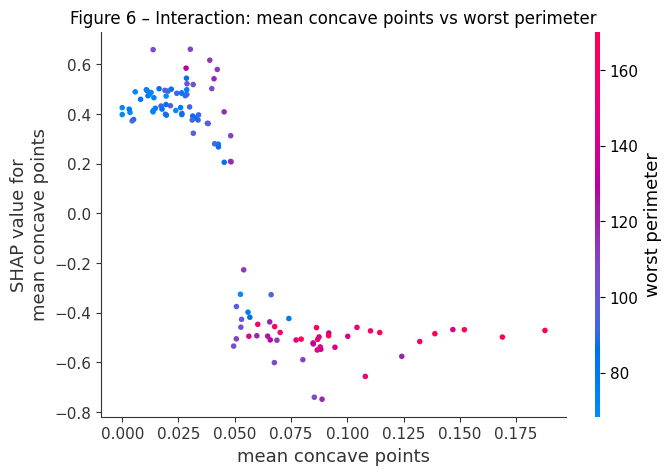

In [ ]:
plt.figure()
shap.dependence_plot(
    feature_1,
    shap_values,
    X_test,
    interaction_index=feature_2,
    show=False
)

plt.title(f"Figure 6 – Interaction: {feature_1} vs {feature_2}")
plt.savefig("figure7_interaction_plot.png", dpi=300, bbox_inches="tight")
plt.show()


- SHAP visualisations indicate that Mean Radius and Mean Texture play strong factors in the predictions.
- SHAP indicates not only the size of feature importance but also whether it is positive or negative.
- Force plots allow for clear interpretation of individual predictions.
- This makes SHAP very useful in highly sensitive applications like healthcare.